Колонки в датасете: ['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']

--- ТАБЛИЦА СТАТИСТИКИ ---
                         mean     std    min      max    range
Humidity                 0.73    0.20   0.00     1.00     1.00
Wind Speed (km/h)       10.81    6.91   0.00    63.85    63.85
Pressure (millibars)  1003.24  116.97   0.00  1046.38  1046.38
Temperature (C)         11.93    9.55 -21.82    39.91    61.73


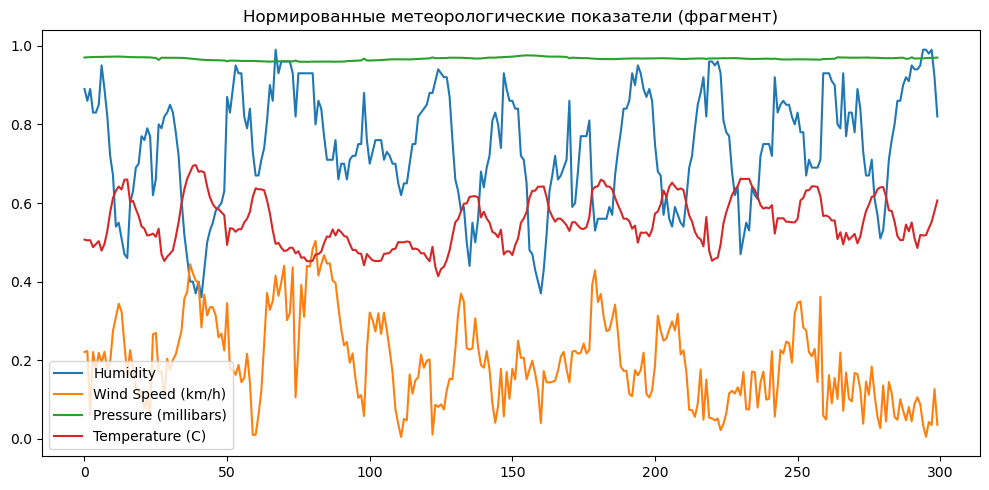


--- РУЧНОЙ РАСЧЕТ (КОЭФФИЦИЕНТЫ) ---
Константа (w0): 38.593799
w_1 (Humidity): -32.439900
w_2 (Wind Speed (km/h)): -0.194547
w_3 (Pressure (millibars)): -0.000716

--- SCIKIT-LEARN РЕЗУЛЬТАТЫ ---
Свободный член (Intercept): 38.593799
Коэффициент Humidity: -32.439900
Коэффициент Wind Speed (km/h): -0.194547
Коэффициент Pressure (millibars): -0.000716

--- МЕТРИКИ КАЧЕСТВА МОДЕЛИ ---
R-squared (R2): 0.4185
MAE: 5.8988
MSE: 53.0481


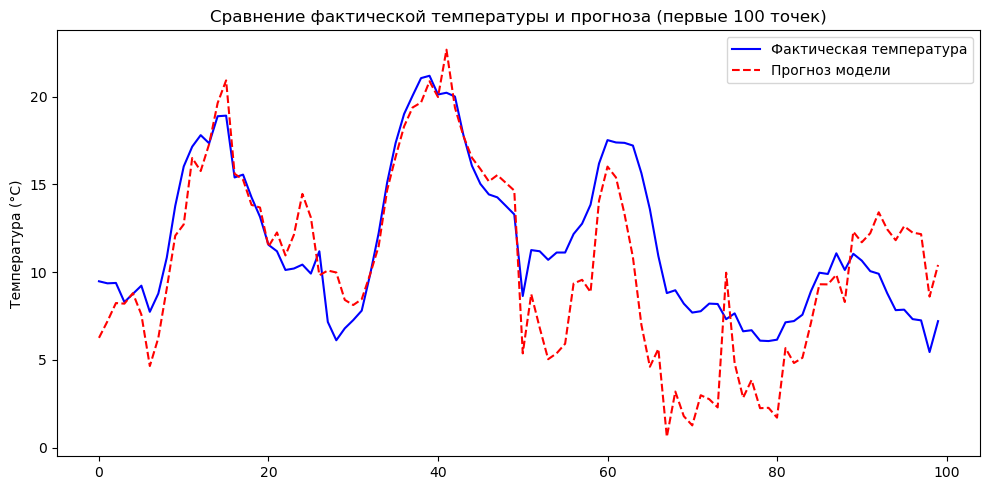

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('weatherHistory.csv')

print("Колонки в датасете:", df.columns.tolist())

feature_cols = ['Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
target_col = 'Temperature (C)'

data = df[feature_cols + [target_col]].dropna()

X_factors = data[feature_cols].values
Y = data[target_col].values

stats = data.describe().transpose()
stats['range'] = stats['max'] - stats['min']
print("\n--- ТАБЛИЦА СТАТИСТИКИ ---")
print(stats[['mean', 'std', 'min', 'max', 'range']].round(2))

plt.figure(figsize=(10, 5))
norm_data = (data - data.min()) / (data.max() - data.min())
for col in norm_data.columns:
    plt.plot(norm_data[col].values[:300], label=col)
plt.title('Нормированные метеорологические показатели (фрагмент)')
plt.legend()
plt.tight_layout()
plt.savefig('weather_dynamics.png')
plt.show()

X_matrix = np.column_stack((np.ones(len(X_factors)), X_factors))

XTX = np.dot(X_matrix.T, X_matrix)
XTX_inv = np.linalg.inv(XTX)
XTY = np.dot(X_matrix.T, Y)
beta_manual = np.dot(XTX_inv, XTY)

print("\n--- РУЧНОЙ РАСЧЕТ (КОЭФФИЦИЕНТЫ) ---")
labels = ['Константа (w0)'] + [f'w_{i+1} ({col})' for i, col in enumerate(feature_cols)]
for label, b in zip(labels, beta_manual):
    print(f"{label}: {b:.6f}")

model = LinearRegression()
model.fit(X_factors, Y)

print("\n--- SCIKIT-LEARN РЕЗУЛЬТАТЫ ---")
print(f"Свободный член (Intercept): {model.intercept_:.6f}")
for col, coef in zip(feature_cols, model.coef_):
    print(f"Коэффициент {col}: {coef:.6f}")

y_pred = model.predict(X_factors)

r2 = r2_score(Y, y_pred)
mae = mean_absolute_error(Y, y_pred)
mse = mean_squared_error(Y, y_pred)

print("\n--- МЕТРИКИ КАЧЕСТВА МОДЕЛИ ---")
print(f"R-squared (R2): {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(Y[:100], label='Фактическая температура', color='blue')
plt.plot(y_pred[:100], label='Прогноз модели', color='red', linestyle='--')
plt.title('Сравнение фактической температуры и прогноза (первые 100 точек)')
plt.ylabel('Температура (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('fact_vs_pred.png')
plt.show()